# Exploratory Data Analysis (EDA)
## Clasificación Multiclase de Incontinencia Urinaria Femenina

La incontinencia urinaria (UI) es una condición frecuente en mujeres adultas y puede clasificarse clínicamente en tres tipos principales:

- **Incontinencia de esfuerzo (stress)**: pérdida de orina al realizar esfuerzos físicos como toser o reír.
- **Incontinencia de urgencia (urge)**: pérdida asociada a una necesidad repentina e intensa de orinar.
- **Incontinencia mixta (mixed)**: combinación de los dos tipos anteriores.

En este proyecto se analizan datos provenientes del estudio nacional de salud de Estados Unidos  
NHANES (National Health and Nutrition Examination Survey), realizado por el CDC.

El dataset incluye **9,074 mujeres adultas entre 2017 y 2023**, con información demográfica, clínica y de estilo de vida.

## Objetivos del EDA

El objetivo de este análisis exploratorio es:

- comprender la estructura del dataset
- identificar problemas de calidad de datos
- explorar relaciones entre variables y tipos de UI
- detectar patrones que puedan ser útiles para modelos predictivos


## 1. Carga de librerías y del dataset

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

sns.set(style="whitegrid")

import warnings
warnings.filterwarnings("ignore")

print("✅ Librerías cargadas correctamente")


✅ Librerías cargadas correctamente


In [2]:
df = pd.read_csv("../../data/raw/nhanes_ui_women.csv")

print("Dimensiones del dataset:")
print(df.shape)

df.head()


Dimensiones del dataset:
(9074, 27)


,id_participante,ciclo_nhanes,peso_encuesta,edad_anios,etnia,pais_nacimiento,imc,dx_hipertension,medicacion_hta_cicloP,medicacion_hta_cicloL,...,ui_cantidad,ui_esfuerzo_presente,ui_esfuerzo_frecuencia,ui_urgencia_presente,ui_urgencia_frecuencia,ui_otro_tipo_presente,ui_molestia_percibida,ui_impacto_actividades,target_tiene_ui,target_tipo_ui
0,109266.0,2017-March2020,NaN,29.0,5.0,2.0,37.8,2.0,NaN,NaN,...,NaN,2.0,NaN,2.0,NaN,2.0,NaN,NaN,0,none
1,109267.0,2017-March2020,NaN,21.0,2.0,2.0,NaN,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,none
2,109284.0,2017-March2020,NaN,44.0,1.0,2.0,39.1,2.0,NaN,NaN,...,1.0,1.0,1.0,2.0,NaN,2.0,2.0,2.0,1,stress
3,109286.0,2017-March2020,NaN,33.0,5.0,2.0,28.9,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,none
4,109290.0,2017-March2020,NaN,68.0,4.0,1.0,28.1,1.0,1.0,NaN,...,2.0,2.0,NaN,1.0,1.0,2.0,2.0,1.0,1,urge


## 2. Exploración inicial del dataset

Primero examinamos la estructura general de los datos:

- número de observaciones
- número de variables
- tipos de datos
- estadísticas descriptivas

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9074 entries, 0 to 9073
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_participante            9074 non-null   float64
 1   ciclo_nhanes               9074 non-null   str    
 2   peso_encuesta              4321 non-null   float64
 3   edad_anios                 9074 non-null   float64
 4   etnia                      9074 non-null   float64
 5   pais_nacimiento            9067 non-null   float64
 6   imc                        7620 non-null   float64
 7   dx_hipertension            9074 non-null   float64
 8   medicacion_hta_cicloP      1694 non-null   float64
 9   medicacion_hta_cicloL      1599 non-null   float64
 10  dx_diabetes                9074 non-null   float64
 11  dx_cancer                  9074 non-null   float64
 12  dx_artritis                9074 non-null   float64
 13  fumadora_alguna_vez        9068 non-null   float64
 14  act

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id_participante,9074.0,126293.524135,10512.947934,1.092660e+05,116673.500000,124146.000000,136317.000000,142310.000000
peso_encuesta,4321.0,29226.384866,28017.570518,5.397605e-79,10936.879472,23493.533031,40807.936171,216127.415939
edad_anios,9074.0,52.077584,17.627592,2.000000e+01,37.000000,54.000000,67.000000,80.000000
etnia,9074.0,3.210712,1.097130,1.000000e+00,3.000000,3.000000,4.000000,5.000000
pais_nacimiento,9067.0,1.295577,1.942076,1.000000e+00,1.000000,1.000000,2.000000,99.000000
imc,7620.0,30.471325,8.212430,1.110000e+01,24.600000,29.000000,34.800000,92.300000
dx_hipertension,9074.0,1.631475,0.542643,1.000000e+00,1.000000,2.000000,2.000000,9.000000
medicacion_hta_cicloP,1694.0,1.139315,0.346377,1.000000e+00,1.000000,1.000000,1.000000,2.000000
medicacion_hta_cicloL,1599.0,1.176986,0.464586,1.000000e+00,1.000000,1.000000,1.000000,9.000000
dx_diabetes,9074.0,1.899713,0.424472,1.000000e+00,2.000000,2.000000,2.000000,9.000000


# Distribución del Target 

## 2. Distribución del tipo de incontinencia urinaria

Antes de construir modelos predictivos es importante entender cómo se distribuye la variable objetivo.

Esto nos permite detectar posibles problemas de **desbalance de clases**.

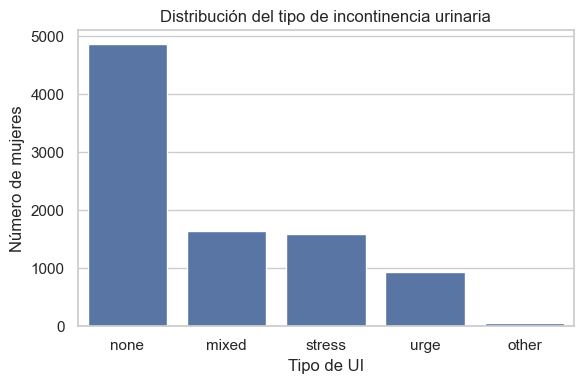

In [5]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="target_tipo_ui",
    order=df["target_tipo_ui"].value_counts().index
)

plt.title("Distribución del tipo de incontinencia urinaria")
plt.xlabel("Tipo de UI")
plt.ylabel("Número de mujeres")

plt.tight_layout()
plt.show()

# Insight
La clase mayoritaria es none con 4,857 mujeres (53.5%), lo que indica que más de la mitad del dataset no presenta incontinencia. Entre las clases positivas, mixed y stress tienen una distribución similar (~18% y ~17.5%), mientras que urge es la menos frecuente con 932 casos (10.3%). La clase other es marginal con solo 57 casos (0.6%) y será evaluada en la fase de ETL.

## 4. Análisis de valores faltantes

Los valores faltantes pueden surgir por múltiples razones:

- Preguntas no aplicables
- Omisiones en la encuesta
- Errores de registro

En este dataset, muchas variables relacionadas con síntomas de UI contienen valores faltantes  
porque **solo se preguntan a participantes que reportan pérdida de orina**.  
Estos nulos son estructurales, no errores.

In [6]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    "missing_values": missing,
    "percentage": missing_percent
})

missing_df = missing_df[missing_df["missing_values"] > 0]
missing_df.sort_values("percentage", ascending=False)


,missing_values,percentage
ui_urgencia_frecuencia,7724,85.122328
medicacion_hta_cicloL,7475,82.378223
medicacion_hta_cicloP,7380,81.331276
ui_esfuerzo_frecuencia,7339,80.879436
ui_molestia_percibida,6706,73.903460
ui_cantidad,5522,60.855191
ui_otro_tipo_presente,5020,55.322901
ui_impacto_actividades,4861,53.570641
peso_encuesta,4753,52.380428
actividad_fisica_vigorosa,4321,47.619572


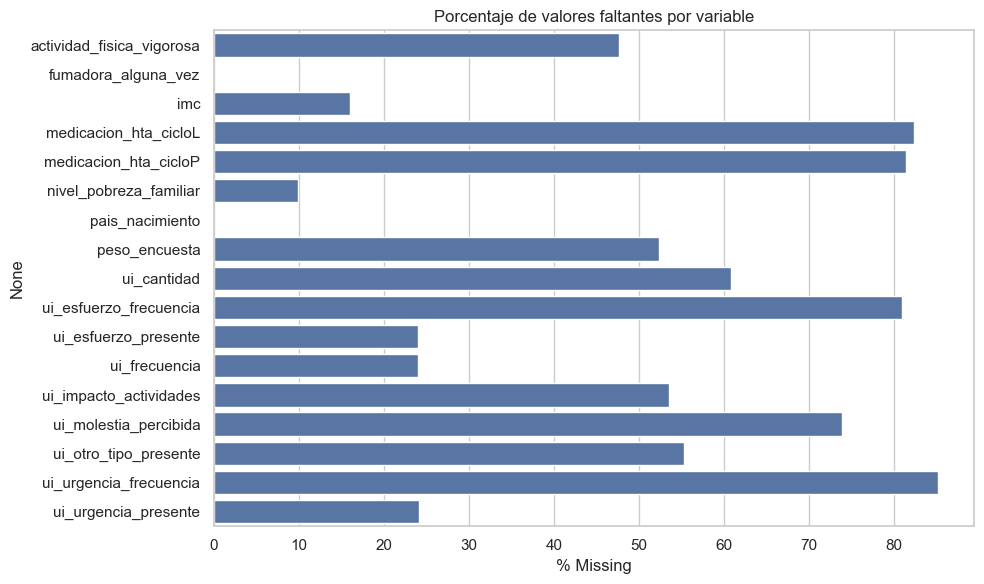

In [7]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=missing_df["percentage"],
    y=missing_df.index
)

plt.title("Porcentaje de valores faltantes por variable")
plt.xlabel("% Missing")

plt.tight_layout()
plt.show()

# Insight
Observamos que en esta grafica vemos todos los valores nulos, mezcla con 85% de nulos junto a variables con 0.07% de nulos en la misma escala, desapareciendo las más pequeñas. Los valores nulos menos del 5% no son muy graves, por ello, en la siguiente grafica mostraremos datos que variables que superan el 5% de nulos, los cuales son importantes para ser tratados en los proximos de ETL.

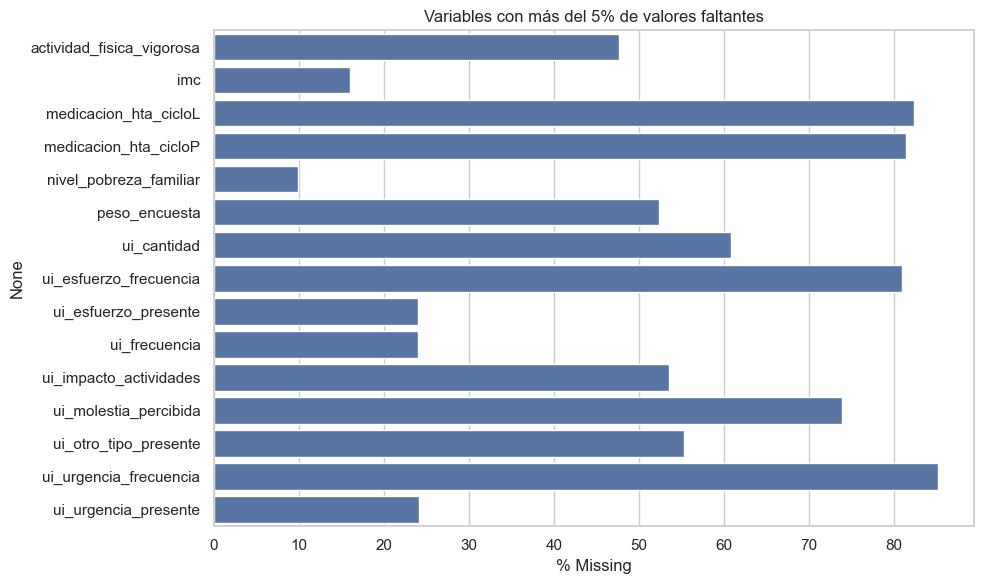

In [8]:
missing_df_filtrado = missing_df[missing_df["percentage"] > 5]

plt.figure(figsize=(10, 6))
sns.barplot(
    x=missing_df_filtrado["percentage"],
    y=missing_df_filtrado.index
)
plt.title("Variables con más del 5% de valores faltantes")
plt.xlabel("% Missing")
plt.tight_layout()
plt.show()

# Insight
Se identifican tres tipos de valores faltantes: nulos estructurales por lógica de la encuesta (síntomas UI solo preguntados a mujeres con pérdida de orina), nulos por diseño del estudio (ciclo 2021-2023 con mediciones presenciales suspendidas por COVID-19), y nulos por no respuesta puntual. Cada tipo requiere una estrategia de imputación diferente en la fase de ETL.

## 5. Análisis univariado

El análisis univariado examina cada variable individualmente.

Esto permite observar:

- Distribución de variables
- Valores extremos
- Posibles errores en los datos


### Variables numéricas

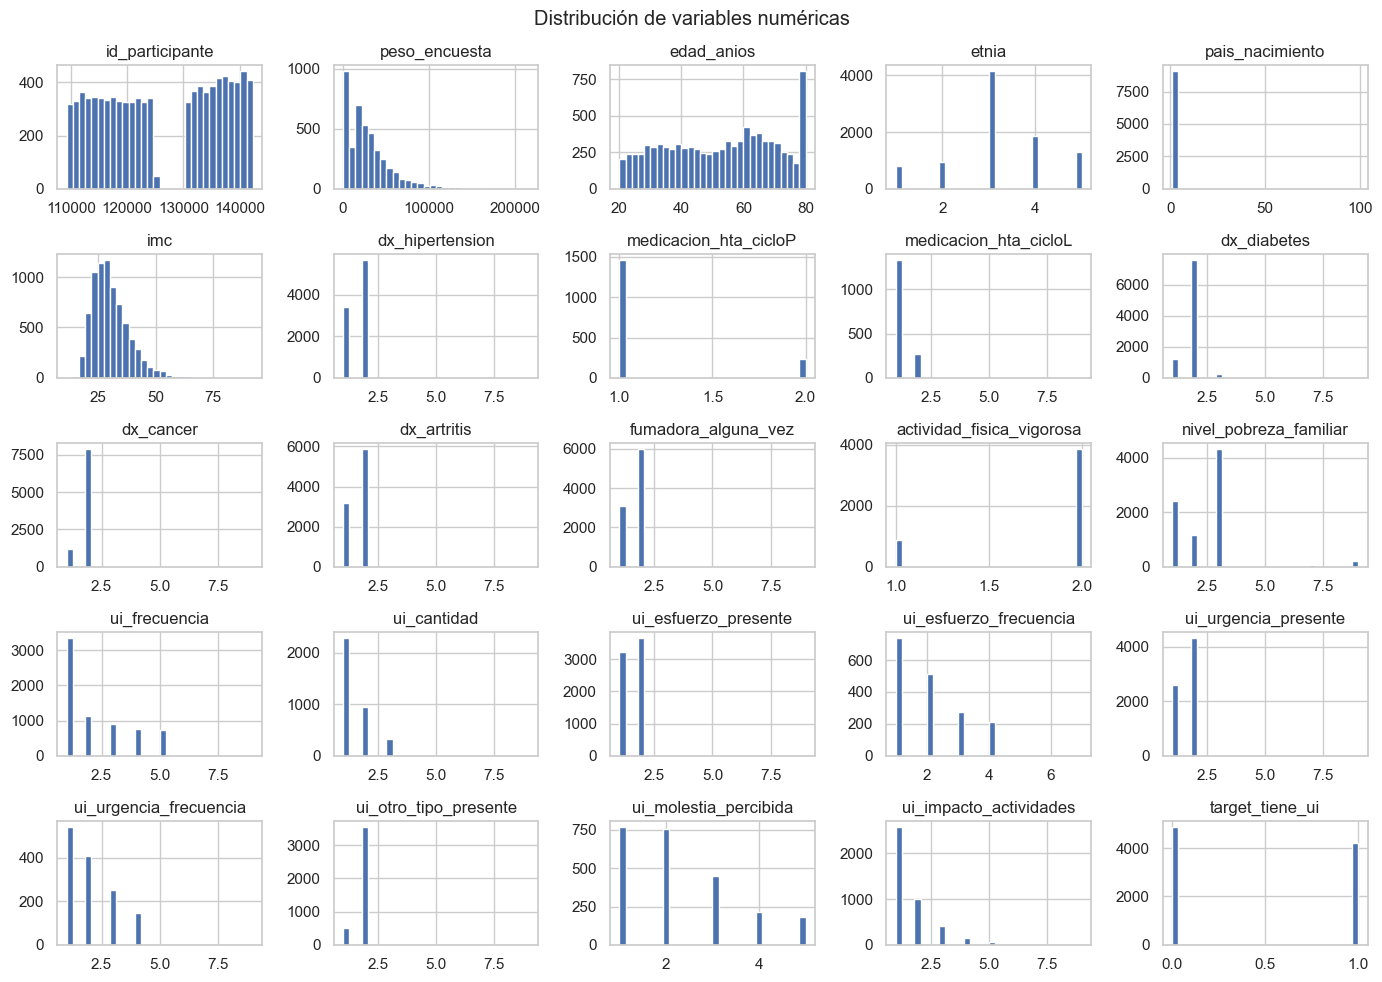

In [9]:
numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns

df[numeric_cols].hist(
    figsize=(14, 10),
    bins=30
)

plt.suptitle("Distribución de variables numéricas")
plt.tight_layout()
plt.show()

# Insight
El análisis univariado revela que las variables clínicas están codificadas numéricamente con valores 1 y 2 (Sí/No), por lo que deberán tratarse como categóricas en el ETL. La edad muestra distribución uniforme con agrupación en 80 años por diseño del CDC. El IMC presenta asimetría positiva con outliers que requieren revisión. Las variables de síntomas UI muestran distribuciones coherentes con la lógica de la encuesta — solo tienen valores las mujeres que reportaron pérdida de orina. El target target_tiene_ui está bien balanceado (~50/50), lo que es favorable para el entrenamiento del modelo.

### Variables categóricas

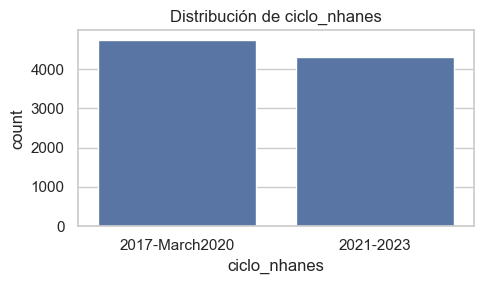

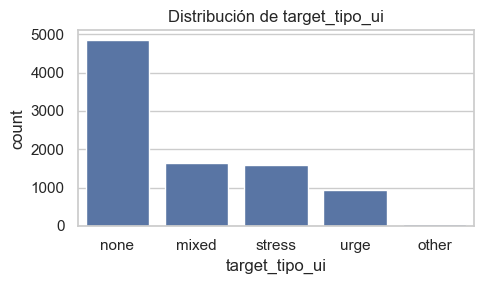

In [10]:
cat_cols = df.select_dtypes(include=["object"]).columns

for col in cat_cols:
    plt.figure(figsize=(5, 3))
    sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index
    )
    plt.title(f"Distribución de {col}")
    plt.tight_layout()
    plt.show()

# Insight
El dataset está distribuido de forma equilibrada entre los dos ciclos NHANES (51% pre-pandemia vs 49% post-pandemia), lo que reduce el riesgo de sesgo temporal en el modelo. Sin embargo, esta división explica parte de los valores faltantes detectados anteriormente — las mediciones presenciales como IMC y actividad física tienen mayor ausencia en el ciclo 2021-2023 debido a la suspensión del estudio por COVID-19. Esto deberá tenerse en cuenta al definir la estrategia de imputación en el ETL: no es lo mismo imputar un dato que nunca se recogió por diseño, que imputar un dato que la participante simplemente no proporcionó.

# Detección de Outliers

## 6. Detección de valores atípicos

Los valores extremos pueden afectar el entrenamiento de modelos de machine learning.

Utilizamos boxplots para detectar posibles outliers en variables continuas como edad e IMC.

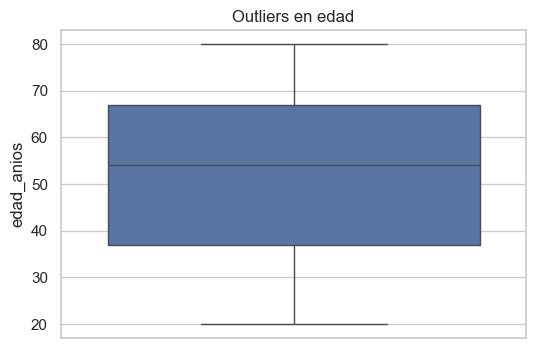

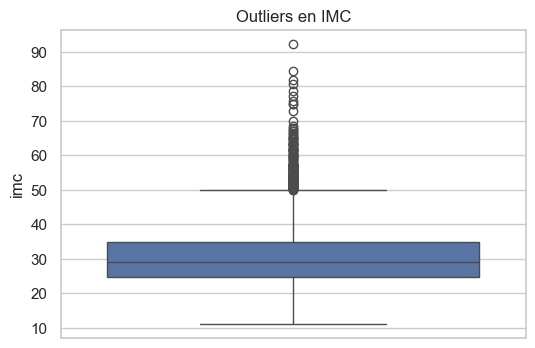

In [11]:
plt.figure(figsize=(6, 4))
sns.boxplot(y=df["edad_anios"])
plt.title("Outliers en edad")
plt.show()

plt.figure(figsize=(6, 4))
sns.boxplot(y=df["imc"])
plt.title("Outliers en IMC")
plt.show()


# Insight
La edad no presenta valores atípicos — su distribución es uniforme entre 20 y 80 años, coherente con el diseño del estudio. El IMC en cambio muestra outliers significativos por encima de 50, con casos extremos cercanos a 90. Dado que estos valores son clínicamente posibles aunque infrecuentes, no se eliminarán sino que se tratarán en el ETL mediante winsorización para reducir su influencia en el modelo sin descartar a las participantes.

## 7. Análisis bivariado

El análisis bivariado examina la relación entre dos variables.

En este caso analizamos cómo variables demográficas y clínicas  
se relacionan con el tipo de incontinencia urinaria.

### Edad vs tipo de UI

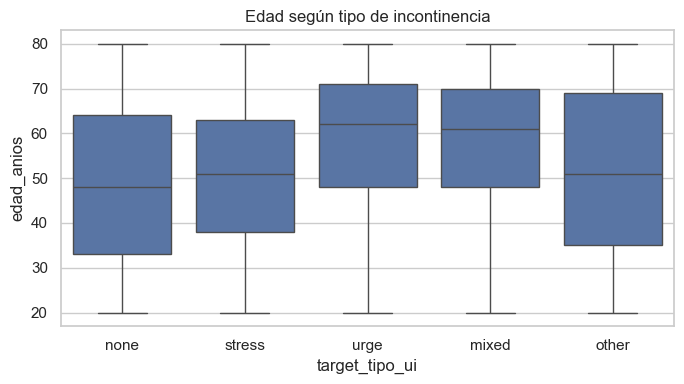

In [12]:
plt.figure(figsize=(7, 4))

sns.boxplot(
    data=df,
    x="target_tipo_ui",
    y="edad_anios"
)

plt.title("Edad según tipo de incontinencia")
plt.tight_layout()
plt.show()


# Insight
La edad muestra una tendencia clara — a mayor edad, mayor probabilidad de incontinencia de urgencia o mixta. Las mujeres sin incontinencia son en promedio unos 10 años más jóvenes que las que presentan urgencia o mixta. Esto sugiere que la edad será una variable predictiva relevante para el modelo.

### IMC vs tipo de UI

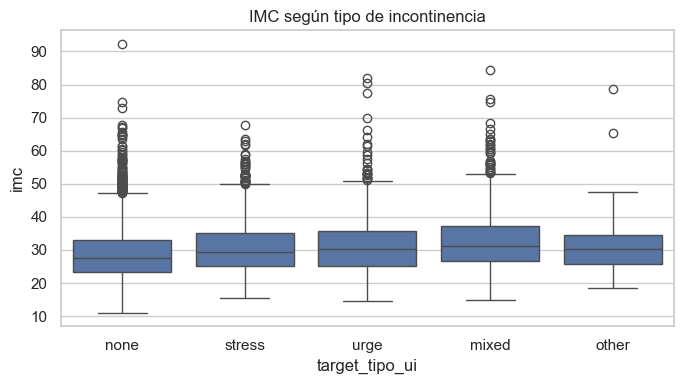

In [13]:
plt.figure(figsize=(7, 4))

sns.boxplot(
    data=df,
    x="target_tipo_ui",
    y="imc"
)

plt.title("IMC según tipo de incontinencia")
plt.tight_layout()
plt.show()


# Insight
El IMC no diferencia claramente entre los distintos tipos de incontinencia — las cuatro clases positivas tienen distribuciones muy similares. Sin embargo, la clase none muestra una mediana levemente inferior, sugiriendo que un IMC más alto se asocia con mayor presencia de UI en general, independientemente del tipo. Los outliers por encima de 70-90 aparecen en todas las clases y serán tratados en el ETL.

### Hipertensión vs tipo de UI

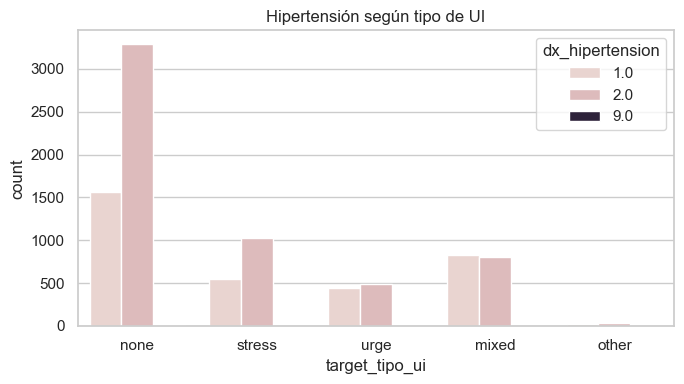

In [14]:
plt.figure(figsize=(7, 4))

sns.countplot(
    data=df,
    x="target_tipo_ui",
    hue="dx_hipertension"
)

plt.title("Hipertensión según tipo de UI")
plt.tight_layout()
plt.show()


# Insight
La hipertensión es más prevalente en mujeres con incontinencia de urgencia y mixta que en mujeres sin incontinencia. Esto es coherente clínicamente ya que ambas condiciones comparten factores de riesgo como la edad avanzada y el sobrepeso. En el ETL deberá tratarse el valor 9.0 que representa respuestas desconocidas.

## 8. Matriz de correlación

La matriz de correlación permite identificar relaciones entre variables numéricas.

Esto puede ayudar a detectar:

- Variables redundantes
- Variables potencialmente predictivas

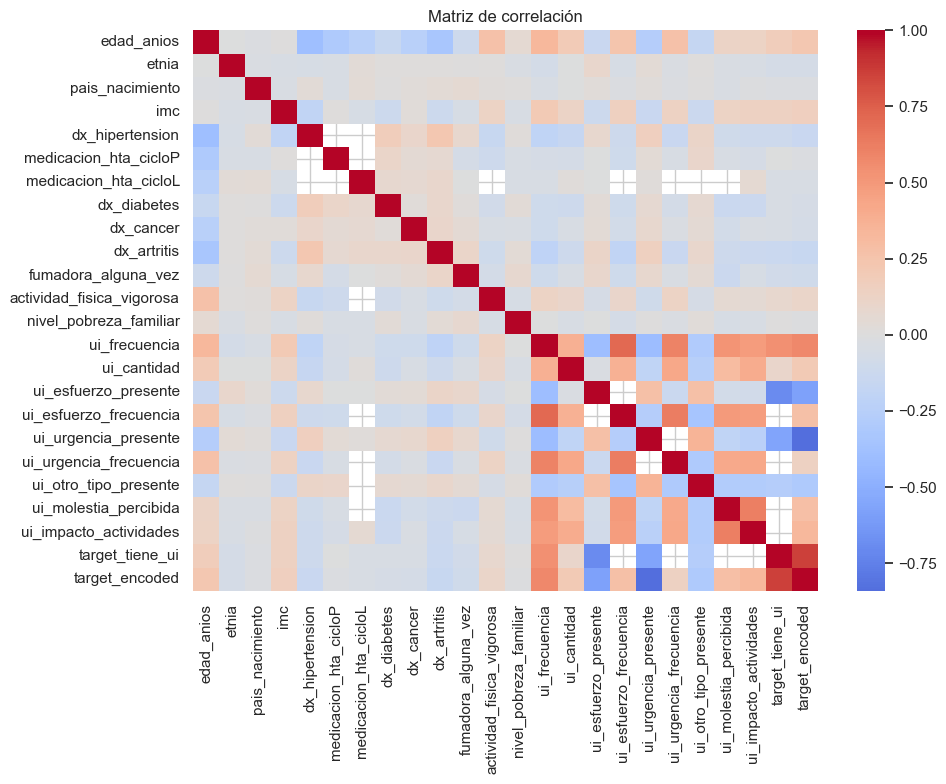

In [15]:
df_corr = df.copy()

# Excluimos columnas sin valor analítico (identificador y peso estadístico)
cols_excluir = ['id_participante', 'peso_encuesta']
df_corr = df_corr.drop(columns=cols_excluir, errors='ignore')

df_corr["target_encoded"] = df_corr["target_tipo_ui"].map({
    "none": 0,
    "stress": 1,
    "urge": 2,
    "mixed": 3
})

corr = df_corr.corr(numeric_only=True)

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()


# Insight
Las variables con mayor correlación con el target son los síntomas directos de UI — frecuencia, cantidad, molestia e impacto en actividades. Las variables clínicas y demográficas muestran correlaciones más débiles pero presentes, lo que sugiere que el modelo se beneficiará de combinar ambos tipos de variables. No se detectan correlaciones muy altas entre variables independientes, lo que indica que no hay multicolinealidad problemática que requiera eliminar variables antes del modelado.

### Variables más correlacionadas con el target

In [16]:
corr_target = corr["target_encoded"].drop("target_encoded").sort_values(ascending=False)

print("Top variables correlacionadas con target_encoded:")
corr_target


Top variables correlacionadas con target_encoded:


target_tiene_ui              0.858991
ui_frecuencia                0.578043
ui_impacto_actividades       0.333069
ui_molestia_percibida        0.281992
ui_esfuerzo_frecuencia       0.275408
edad_anios                   0.225031
ui_cantidad                  0.205309
imc                          0.163293
ui_urgencia_frecuencia       0.145385
actividad_fisica_vigorosa    0.101462
nivel_pobreza_familiar      -0.008368
medicacion_hta_cicloP       -0.018497
pais_nacimiento             -0.019890
medicacion_hta_cicloL       -0.037627
dx_diabetes                 -0.063730
dx_cancer                   -0.066926
etnia                       -0.068264
fumadora_alguna_vez         -0.098104
dx_hipertension             -0.141620
dx_artritis                 -0.153267
ui_otro_tipo_presente       -0.296318
ui_esfuerzo_presente        -0.576698
ui_urgencia_presente        -0.840895
Name: target_encoded, dtype: float64

# Insight
Las variables con mayor poder predictivo sobre el tipo de incontinencia son los síntomas directos — especialmente la frecuencia de pérdida, la presencia de urgencia y de esfuerzo. La edad y el IMC tienen correlación moderada. Las variables clínicas como hipertensión y artritis tienen correlación débil pero no despreciable, por lo que se mantendrán como features en el modelo.

## Conclusiones del análisis exploratorio

El análisis exploratorio del dataset NHANES revela los siguientes hallazgos clave:

### Sobre el dataset
- El dataset contiene **9,074 mujeres adultas** distribuidas de forma equilibrada 
entre dos ciclos NHANES: 51% pre-pandemia (2017-March2020) y 49% 
post-pandemia (2021-2023).
- Esta división temporal explica parte de los valores faltantes detectados — 
las mediciones presenciales como IMC y actividad física tienen mayor ausencia 
en el ciclo 2021-2023 por la suspensión del estudio durante el COVID-19.

### Sobre el target
- Aproximadamente el **53.5% de las mujeres no presenta incontinencia** (`none`), 
y el 46.5% restante se distribuye entre los tres tipos positivos.
- La clase **urgencia es la menos frecuente** (~10%), lo que generará desbalance 
de clases que deberá corregirse con SMOTE en la fase de modelado.
- Existe una clase marginal `other` (57 casos, 0.6%) que por criterio clínico 
se fusionará con `urge` en el ETL.

### Sobre los valores faltantes
- Se identifican **tres tipos de nulos** con estrategias distintas en el ETL:
  - **Estructurales**: síntomas UI solo preguntados a mujeres con pérdida de 
  orina — no son errores
  - **Por diseño del estudio**: mediciones presenciales no recogidas en 
  2021-2023 por COVID-19
  - **Por no respuesta**: casos puntuales como `imc` (16%) y 
  `nivel_pobreza_familiar` (10%) que se imputarán con mediana y moda

### Sobre las variables
- La **edad** muestra una tendencia clara — las mujeres con urgencia y mixta 
son en promedio ~10 años mayores que las mujeres sin incontinencia.
- El **IMC** presenta outliers extremos (hasta 90) que serán tratados con 
winsorización en el ETL. Las mujeres con UI tienen IMC ligeramente mayor.
- Las **comorbilidades** como hipertensión y artritis son más prevalentes en 
mujeres con UI, especialmente en urgencia y mixta.
- Las variables codificadas con valor **9.0** (no sabe/no responde) deberán 
tratarse en el ETL.

### Sobre la correlación
- Las variables con **mayor poder predictivo** son los síntomas directos: 
`ui_frecuencia` (0.58), `ui_urgencia_presente` (-0.84) y 
`ui_esfuerzo_presente` (-0.58).
- La edad (0.23) y el IMC (0.16) tienen correlación moderada con el target.
- No se detecta multicolinealidad problemática entre variables independientes.

### Próximos pasos — ETL
1. Fusionar `other` → `urge`
2. Tratar valores 9.0 en variables clínicas
3. Winsorización del IMC
4. Imputar `imc` con mediana e `nivel_pobreza_familiar` con moda
5. Encoding de variables categóricas
6. SMOTE selectivo sobre clase `urge`
7. Split estratificado train/val/test (70/15/15)

# ETL — Extracción, Transformación y Carga
## Clasificación Multiclase de Incontinencia Urinaria Femenina

Este notebook ejecuta los pasos de **limpieza y preparación** de datos  
definidos en las conclusiones del EDA.

El objetivo es transformar el dataset crudo en un dataset limpio  
listo para el modelado.

| Paso | Acción |
|------|--------|
| 1 | Fusionar clase `other` → `urge` |
| 2 | Tratar valores 9.0 en variables clínicas |
| 3 | Winsorización del IMC |
| 4 | Imputación de valores nulos |
| 5 | Encoding y selección de features |


## Paso 1 — Fusionar clase `other` con `urge`

La clase `other` (57 casos, 0.6%) corresponde a pérdidas sin causa claramente identificable.  
Por criterio clínico se fusiona con `urge`, quedando **4 clases finales**.

Clases después de fusión:
target_tipo_ui
none      4857
mixed     1642
stress    1586
urge       989
Name: count, dtype: int64


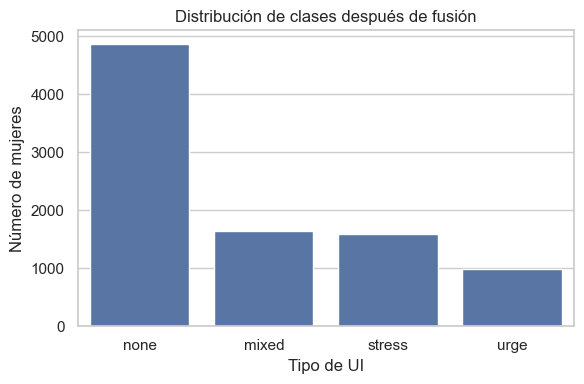


✅ Paso 1 completado


In [26]:
df_etl = df.copy()

df_etl['target_tipo_ui'] = df_etl['target_tipo_ui'].replace('other', 'urge')

print("Clases después de fusión:")
print(df_etl['target_tipo_ui'].value_counts())

# Verificación visual
plt.figure(figsize=(6, 4))
sns.countplot(
    data=df_etl,
    x='target_tipo_ui',
    order=df_etl['target_tipo_ui'].value_counts().index
)
plt.title("Distribución de clases después de fusión")
plt.xlabel("Tipo de UI")
plt.ylabel("Número de mujeres")
plt.tight_layout()
plt.show()

print("\n✅ Paso 1 completado")


## Paso 2 — Tratar valores 9.0 en variables clínicas

En NHANES el valor **9.0** significa "no sabe / no responde".  
No es un dato real — se reemplaza por `NaN` para imputarlo correctamente en el paso siguiente.

In [27]:
vars_clinicas = [
    'dx_hipertension', 'dx_diabetes', 'dx_cancer',
    'dx_artritis', 'fumadora_alguna_vez', 'actividad_fisica_vigorosa',
    'medicacion_hta_cicloP', 'medicacion_hta_cicloL'
]

print("Valores 9.0 encontrados y reemplazados por NaN:")
encontrados = False
for col in vars_clinicas:
    n = (df_etl[col] == 9.0).sum()
    if n > 0:
        df_etl[col] = df_etl[col].replace(9.0, np.nan)
        print(f"  {col}: {n} valores reemplazados")
        encontrados = True

if not encontrados:
    print("  No se encontraron valores 9.0")

print("\n✅ Paso 2 completado")


Valores 9.0 encontrados y reemplazados por NaN:
  dx_hipertension: 10 valores reemplazados
  dx_diabetes: 5 valores reemplazados
  dx_cancer: 6 valores reemplazados
  dx_artritis: 27 valores reemplazados
  fumadora_alguna_vez: 4 valores reemplazados
  medicacion_hta_cicloL: 2 valores reemplazados

✅ Paso 2 completado


## Paso 3 — Winsorización del IMC

Los valores extremos de IMC (hasta 90) son clínicamente posibles  
pero pueden distorsionar el modelo.

Se aplica winsorización al **percentil 99** — los valores por encima  
se recortan a ese límite, conservando las filas sin eliminarlas.

Límite de winsorización (percentil 99): 56.3
Casos recortados: 77


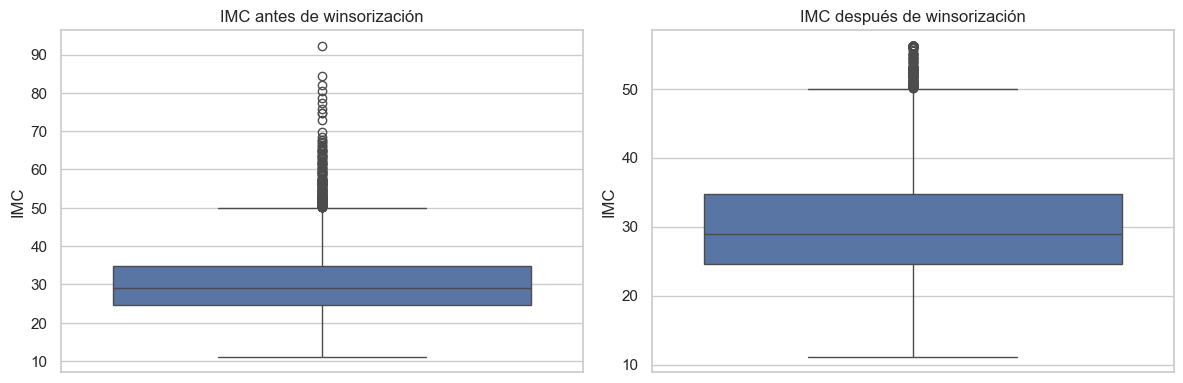

IMC máximo antes:  92.3
IMC máximo después: 56.3

✅ Paso 3 completado


In [28]:
limite_imc = df_etl['imc'].quantile(0.99)
print(f"Límite de winsorización (percentil 99): {limite_imc:.1f}")

n_outliers = (df_etl['imc'] > limite_imc).sum()
print(f"Casos recortados: {n_outliers}")

df_etl['imc'] = df_etl['imc'].clip(upper=limite_imc)

# Verificación visual — antes vs después
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(y=df['imc'], ax=axes[0])
axes[0].set_title("IMC antes de winsorización")
axes[0].set_ylabel("IMC")

sns.boxplot(y=df_etl['imc'], ax=axes[1])
axes[1].set_title("IMC después de winsorización")
axes[1].set_ylabel("IMC")

plt.tight_layout()
plt.show()

print(f"IMC máximo antes:  {df['imc'].max():.1f}")
print(f"IMC máximo después: {df_etl['imc'].max():.1f}")
print("\n✅ Paso 3 completado")


## Paso 4 — Imputación de valores nulos

Estrategia por tipo de variable:

| Variable | Estrategia | Motivo |
|----------|-----------|--------|
| `imc` | Mediana | Variable continua con distribución asimétrica |
| `nivel_pobreza_familiar` | Moda | Variable ordinal |
| `pais_nacimiento` | Moda | Solo 7 nulos |
| Variables clínicas binarias | Moda | Variables categóricas |
| Síntomas UI | Se mantienen como `NaN` | Nulos estructurales — significa "no tiene ese síntoma" |


In [29]:
print("Nulos antes de imputación:")
nulos_antes = df_etl.isnull().sum()[df_etl.isnull().sum() > 0].sort_values(ascending=False)
print(nulos_antes)


Nulos antes de imputación:
ui_urgencia_frecuencia       7724
medicacion_hta_cicloL        7477
medicacion_hta_cicloP        7380
ui_esfuerzo_frecuencia       7339
ui_molestia_percibida        6706
ui_cantidad                  5522
ui_otro_tipo_presente        5020
ui_impacto_actividades       4861
peso_encuesta                4753
actividad_fisica_vigorosa    4321
ui_urgencia_presente         2190
ui_esfuerzo_presente         2185
ui_frecuencia                2180
imc                          1454
nivel_pobreza_familiar        905
dx_artritis                    27
fumadora_alguna_vez            10
dx_hipertension                10
pais_nacimiento                 7
dx_cancer                       6
dx_diabetes                     5
dtype: int64


In [30]:
# imc → mediana
mediana_imc = df_etl['imc'].median()
df_etl['imc'] = df_etl['imc'].fillna(mediana_imc)
print(f"imc imputado con mediana: {mediana_imc:.1f}")

# nivel_pobreza_familiar → moda
moda_pobreza = df_etl['nivel_pobreza_familiar'].mode()[0]
df_etl['nivel_pobreza_familiar'] = df_etl['nivel_pobreza_familiar'].fillna(moda_pobreza)
print(f"nivel_pobreza_familiar imputado con moda: {moda_pobreza}")

# pais_nacimiento → moda
moda_pais = df_etl['pais_nacimiento'].mode()[0]
df_etl['pais_nacimiento'] = df_etl['pais_nacimiento'].fillna(moda_pais)
print(f"pais_nacimiento imputado con moda: {moda_pais}")

# Variables clínicas → moda
for col in vars_clinicas:
    if df_etl[col].isnull().sum() > 0:
        moda = df_etl[col].mode()[0]
        df_etl[col] = df_etl[col].fillna(moda)
        print(f"{col} imputado con moda: {moda}")

print("\nNulos restantes (estructurales de síntomas UI — se mantienen):")
nulos_restantes = df_etl.isnull().sum()[df_etl.isnull().sum() > 0]
print(nulos_restantes if len(nulos_restantes) > 0 else "Ninguno")
print("\n✅ Paso 4 completado")


imc imputado con mediana: 29.0
nivel_pobreza_familiar imputado con moda: 3.0
pais_nacimiento imputado con moda: 1.0
dx_hipertension imputado con moda: 2.0
dx_diabetes imputado con moda: 2.0
dx_cancer imputado con moda: 2.0
dx_artritis imputado con moda: 2.0
fumadora_alguna_vez imputado con moda: 2.0
actividad_fisica_vigorosa imputado con moda: 2.0
medicacion_hta_cicloP imputado con moda: 1.0
medicacion_hta_cicloL imputado con moda: 1.0

Nulos restantes (estructurales de síntomas UI — se mantienen):
peso_encuesta             4753
ui_frecuencia             2180
ui_cantidad               5522
ui_esfuerzo_presente      2185
ui_esfuerzo_frecuencia    7339
ui_urgencia_presente      2190
ui_urgencia_frecuencia    7724
ui_otro_tipo_presente     5020
ui_molestia_percibida     6706
ui_impacto_actividades    4861
dtype: int64

✅ Paso 4 completado


## Paso 5 — Encoding y selección de features

Se eliminan columnas que no aportan valor predictivo:

| Columna | Motivo de eliminación |
|---------|----------------------|
| `id_participante` | Identificador, no es una feature |
| `peso_encuesta` | Peso estadístico del CDC, no predictivo |
| `ciclo_nhanes` | Variable de diseño del estudio |
| `target_tiene_ui` | Target binario redundante con `target_tipo_ui` |

In [31]:
# Eliminar columnas no predictivas
cols_eliminar = ['id_participante', 'peso_encuesta', 'ciclo_nhanes', 'target_tiene_ui']
df_etl = df_etl.drop(columns=cols_eliminar, errors='ignore')

print(f"Columnas eliminadas: {cols_eliminar}")
print(f"\nDataset limpio: {df_etl.shape[0]:,} filas × {df_etl.shape[1]} columnas")
print(f"\nFeatures finales:")
features = [c for c in df_etl.columns if c != 'target_tipo_ui']
for f in features:
    print(f"  {f}")


Columnas eliminadas: ['id_participante', 'peso_encuesta', 'ciclo_nhanes', 'target_tiene_ui']

Dataset limpio: 9,074 filas × 23 columnas

Features finales:
  edad_anios
  etnia
  pais_nacimiento
  imc
  dx_hipertension
  medicacion_hta_cicloP
  medicacion_hta_cicloL
  dx_diabetes
  dx_cancer
  dx_artritis
  fumadora_alguna_vez
  actividad_fisica_vigorosa
  nivel_pobreza_familiar
  ui_frecuencia
  ui_cantidad
  ui_esfuerzo_presente
  ui_esfuerzo_frecuencia
  ui_urgencia_presente
  ui_urgencia_frecuencia
  ui_otro_tipo_presente
  ui_molestia_percibida
  ui_impacto_actividades


## Guardar dataset limpio

Se guarda el dataset procesado en `data/processed/`  
listo para ser usado en el notebook de modelado.


In [32]:
import os
os.makedirs("../../data/processed", exist_ok=True)

df_etl.to_csv("../../data/processed/nhanes_ui_cleaned.csv", index=False)

print(f"✅ Dataset limpio guardado en data/processed/nhanes_ui_cleaned.csv")
print(f"   Shape: {df_etl.shape[0]:,} filas × {df_etl.shape[1]} columnas")
print(f"\nPrimeras filas:")
df_etl.head()


✅ Dataset limpio guardado en data/processed/nhanes_ui_cleaned.csv
   Shape: 9,074 filas × 23 columnas

Primeras filas:


,edad_anios,etnia,pais_nacimiento,imc,dx_hipertension,medicacion_hta_cicloP,medicacion_hta_cicloL,dx_diabetes,dx_cancer,dx_artritis,...,ui_frecuencia,ui_cantidad,ui_esfuerzo_presente,ui_esfuerzo_frecuencia,ui_urgencia_presente,ui_urgencia_frecuencia,ui_otro_tipo_presente,ui_molestia_percibida,ui_impacto_actividades,target_tipo_ui
0,29.0,5.0,2.0,37.8,2.0,1.0,1.0,2.0,2.0,2.0,...,1.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,NaN,none
1,21.0,2.0,2.0,29.0,2.0,1.0,1.0,2.0,2.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,none
2,44.0,1.0,2.0,39.1,2.0,1.0,1.0,2.0,2.0,2.0,...,4.0,1.0,1.0,1.0,2.0,NaN,2.0,2.0,2.0,stress
3,33.0,5.0,2.0,28.9,2.0,1.0,1.0,2.0,2.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,none
4,68.0,4.0,1.0,28.1,1.0,1.0,1.0,1.0,2.0,1.0,...,3.0,2.0,2.0,NaN,1.0,1.0,2.0,2.0,1.0,urge


## Resumen del ETL

| Paso | Acción | Resultado |
|------|--------|-----------|
| 1 | Fusión `other` → `urge` | 4 clases finales limpias |
| 2 | Tratamiento valores 9.0 | Reemplazados por NaN en variables clínicas |
| 3 | Winsorización IMC | Outliers recortados al percentil 99 |
| 4 | Imputación nulos | Mediana para IMC, moda para el resto |
| 5 | Encoding y selección de features | 4 columnas eliminadas |

**Dataset guardado:** `data/processed/nhanes_ui_cleaned.csv`

**Próximo paso:** Notebook de modelado — split estratificado, SMOTE y entrenamiento del modelo ensemble.
